# Advanced Matrix Calculus for Machine Learning (Part 1)

## Fréchet Derivatives, Vectorization, and Automatic Differentiation

*Based on MIT 18.S096 / 18.063 — "Matrix Calculus for Machine Learning and Beyond"*

**Core philosophy:** Derivatives are **linear operators**, not arrays of partial
derivatives.  Matrices are holistic objects; we differentiate them as such.

> "The derivative $f'(x)$ is the linear map that best approximates $f$ near $x$."

### Roadmap (this notebook — Part 1)
1. **Derivatives as Linear Operators** — the Fréchet derivative
2. **Matrix-Valued Functions & Vectorization** — Kronecker products, `vec`
3. **Forward-Mode vs. Reverse-Mode Differentiation** — why backprop works

In [1]:
import numpy as np
from numpy.linalg import norm, inv
from scipy.linalg import kron
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools, time

np.set_printoptions(precision=6, suppress=True, linewidth=120)
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "lines.linewidth": 2,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
rng = np.random.default_rng(42)
print("Setup complete ✓")

Setup complete ✓


---
## Section 1 — Derivatives as Linear Operators (Fréchet Derivatives)

### 1.1  Why the schoolbook definition breaks down

For $f:\mathbb{R}\to\mathbb{R}$ the derivative is

$$
f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}.
$$

This requires **dividing by $h$**.  When $f:\mathbb{R}^n\to\mathbb{R}^m$ (or
$f$ maps matrices to matrices), "dividing by a vector / matrix" makes no sense.

### 1.2  The Fréchet derivative

The correct generalisation: $f'(x)$ is a **linear map** acting on perturbations
$\delta x$:

$$
f(x+\delta x) = f(x) + \underbrace{f'(x)[\delta x]}_{\text{linear in }\delta x}
  + o(\|\delta x\|)
$$

where $o(\|\delta x\|)$ denotes a remainder that vanishes **faster** than
$\|\delta x\|$:

$$
g(\delta x) = o(\|\delta x\|) \;\Longleftrightarrow\;
  \lim_{\|\delta x\|\to 0}\frac{\|g(\delta x)\|}{\|\delta x\|}=0.
$$

The derivative **is** the linear part of the first-order perturbation.

### 1.3  Worked examples

| Function | Expansion | Derivative $f'(x)[\delta x]$ |
|---|---|---|
| $f(x)=Ax$ (linear) | $A(x+\delta x)=Ax+A\delta x$ | $A\delta x$ — the derivative **is** $A$ itself |
| $f(x)=x^\top Ax$ (quadratic form) | $=x^\top Ax + x^\top(A+A^\top)\delta x + \delta x^\top A\delta x$ | $x^\top(A+A^\top)\delta x$ (scalar);  $\delta x^\top A\delta x=o(\|\delta x\|)$.  When $A$ is symmetric this simplifies to $2x^\top A\,\delta x$. |
| $f(A)=A^2$ (matrix-valued) | $=(A+\delta A)^2 = A^2+A\,\delta A+\delta A\,A+\delta A^2$ | $A\,\delta A+\delta A\,A$ (**not** $2A\,\delta A$ — non-commutativity!) |

### 1.4  Jacobian = matrix representation of the linear operator

The Jacobian $J\in\mathbb{R}^{m\times n}$ is the matrix such that
$f'(x)[\delta x]=J\,\delta x$ (when both input and output are vectors in the
standard basis).  The linear operator is basis-free; the Jacobian depends on the
chosen bases.

### 1.5  Gradient ≠ Derivative

For $f:\mathbb{R}^n\to\mathbb{R}$:

| Object | Lives in | Acts as |
|---|---|---|
| Derivative $f'(x)$ | dual space / row vector / 1-form | $f'(x)[\delta x] = J\,\delta x$ |
| Gradient $\nabla f(x)$ | primal space / column vector | $f'(x)[\delta x] = \langle\nabla f,\,\delta x\rangle$ |

They are related by the **Riesz representation theorem**: the gradient is the
"metric dual" of the derivative:

$$
\nabla f = J^\top \qquad\text{(with the standard Euclidean inner product).}
$$

> 💡 **Physicist's Intuition:** derivative = covector (covariant, lower index),
> gradient = vector (contravariant, upper index).  They're related by
> $g^{\mu\nu}$, the metric.  In flat Euclidean space with orthonormal coords
> the metric is $\delta^{\mu\nu}$ so the distinction looks trivial — but it's
> *conceptually* crucial.

> ⚠️ **Common Misconception:** "gradient and derivative are the same."
> They coincide *numerically* in Euclidean space with the standard basis, but
> they are different *objects*: the derivative is a linear functional (row
> vector), the gradient is a vector (column vector).

In [2]:
# --- 1.1  Verify f(x) = x'Ax derivative with finite differences ---

n = 5
A = rng.standard_normal((n, n))
x = rng.standard_normal(n)

def f_quad(x):
    return x @ A @ x

# Analytical derivative: f'(x)[δx] = x'(A+A')δx  →  Jacobian row = x'(A+A')
# (reduces to 2x'A when A is symmetric)
jac_analytic = x @ (A + A.T)  # shape (n,)

# Finite-difference Jacobian (central differences)
eps = 1e-7
jac_fd = np.zeros(n)
for i in range(n):
    e_i = np.zeros(n); e_i[i] = 1.0
    jac_fd[i] = (f_quad(x + eps*e_i) - f_quad(x - eps*e_i)) / (2*eps)

print("f(x) = x'Ax  (derivative row vector = x'(A+A'), or 2x'A when A symmetric)")
print(f"  Analytic Jacobian: {jac_analytic}")
print(f"  Finite-diff Jac : {jac_fd}")
print(f"  Max error        : {np.max(np.abs(jac_analytic - jac_fd)):.2e}")
assert np.allclose(jac_analytic, jac_fd, atol=1e-5), "Mismatch!"
print("  ✓ Verified\n")

f(x) = x'Ax  (derivative row vector = x'(A+A'), or 2x'A when A symmetric)
  Analytic Jacobian: [-1.752385  0.613919  0.51762   0.857299  0.099741]
  Finite-diff Jac : [-1.752385  0.613919  0.51762   0.857299  0.099741]
  Max error        : 8.43e-10
  ✓ Verified



In [3]:
# --- 1.2  Verify f(A) = A² derivative:  f'(A)[δA] = AδA + δA·A ---

m = 4
A = rng.standard_normal((m, m))
dA = rng.standard_normal((m, m)) * 1e-7  # small perturbation

# Analytical linear term
linear_analytic = A @ dA + dA @ A

# Finite-difference linear term
f_plus  = (A + dA) @ (A + dA)  # = A² + AδA + δA·A + δA²
f_minus = A @ A
linear_fd = f_plus - f_minus  # ≈ AδA + δA·A  (+ O(||δA||²))

print("f(A) = A²  →  f'(A)[δA] = AδA + δA·A")
print(f"  ||Analytic||    = {norm(linear_analytic):.8f}")
print(f"  ||Finite-diff|| = {norm(linear_fd):.8f}")
print(f"  Relative error  = {norm(linear_analytic - linear_fd)/norm(linear_analytic):.2e}")
assert np.allclose(linear_analytic, linear_fd, atol=1e-5), "Mismatch!"

# Show that the WRONG formula 2A·δA gives a different answer
wrong = 2 * A @ dA
print(f"\n  Wrong formula 2AδA relative error from FD = "
      f"{norm(wrong - linear_fd)/norm(linear_fd):.4f}")
print("  (non-trivial error → 2AδA is WRONG for non-commuting matrices)")
print("  ✓ Correct derivative verified\n")

f(A) = A²  →  f'(A)[δA] = AδA + δA·A
  ||Analytic||    = 0.00000089
  ||Finite-diff|| = 0.00000089
  Relative error  = 5.95e-08

  Wrong formula 2AδA relative error from FD = 0.6379
  (non-trivial error → 2AδA is WRONG for non-commuting matrices)
  ✓ Correct derivative verified



In [4]:
# --- 1.3  Gradient vs Derivative for f(x) = x'Ax ---

# For f(x) = x'Ax:
#   Jacobian (derivative, row vector): J = x'(A + A')
#   Gradient (column vector):          ∇f = (A + A')x
# These are transposes of each other: ∇f = J'.
# For symmetric A:  A + A' = 2A, so J = 2x'A, ∇f = 2Ax.

n = 5
A_sym = rng.standard_normal((n, n))
A_sym = A_sym + A_sym.T  # symmetric
x = rng.standard_normal(n)

# Derivative (Jacobian row) and gradient for symmetric A
deriv_row = x @ (A_sym + A_sym.T)  # = 2 x'A since A is symmetric
grad_col  = (A_sym + A_sym.T) @ x  # = 2Ax

print("f(x) = x'Ax with A symmetric")
print(f"  Derivative (row vec) x'(A+A') = 2x'A : {deriv_row}")
print(f"  Gradient   (col vec) (A+A')x  = 2Ax  : {grad_col}")
print(f"  Numerically equal (∇f = J' same as 1D array): {np.allclose(deriv_row, grad_col)}")

# General (non-symmetric) case
A_gen = rng.standard_normal((n, n))
x = rng.standard_normal(n)
deriv_gen = x @ (A_gen + A_gen.T)   # Jacobian row = x'(A + A')
grad_gen  = (A_gen + A_gen.T) @ x   # Gradient = (A + A')x
print(f"\n  Non-symmetric A:")
print(f"  Derivative x'(A+A'): {deriv_gen}")
print(f"  Gradient  (A+A')x  : {grad_gen}")
print(f"  ∇f = J' (same as 1D): {np.allclose(deriv_gen, grad_gen)}")
print("  (In 1D numpy arrays, row and column are the same object;")
print("   the distinction matters conceptually: J acts on δx, ∇f has inner product.)")

# Verify gradient via finite differences
def f_gen(x):
    return x @ A_gen @ x
grad_fd = np.zeros(n)
eps = 1e-7
for i in range(n):
    e_i = np.zeros(n); e_i[i] = 1.0
    grad_fd[i] = (f_gen(x + eps*e_i) - f_gen(x - eps*e_i)) / (2*eps)
print(f"\n  Gradient (finite-diff): {grad_fd}")
print(f"  Gradient (A+A')x     : {grad_gen}")
print(f"  Match: {np.allclose(grad_fd, grad_gen, atol=1e-5)}  ✓")

f(x) = x'Ax with A symmetric
  Derivative (row vec) x'(A+A') = 2x'A : [ 1.348219  1.359408  1.370176  0.98929  -2.971901]
  Gradient   (col vec) (A+A')x  = 2Ax  : [ 1.348219  1.359408  1.370176  0.98929  -2.971901]
  Numerically equal (∇f = J' same as 1D array): True

  Non-symmetric A:
  Derivative x'(A+A'): [0.230058 0.798041 1.954024 0.222272 0.315092]
  Gradient  (A+A')x  : [0.230058 0.798041 1.954024 0.222272 0.315092]
  ∇f = J' (same as 1D): True
  (In 1D numpy arrays, row and column are the same object;
   the distinction matters conceptually: J acts on δx, ∇f has inner product.)

  Gradient (finite-diff): [0.230058 0.798041 1.954024 0.222272 0.315092]
  Gradient (A+A')x     : [0.230058 0.798041 1.954024 0.222272 0.315092]
  Match: True  ✓


---
## Section 2 — Matrix-Valued Functions & Vectorization

### 2.1  Non-commutativity is everything

For $f(A)=A^3$ the expansion is

$$
(A+\delta A)^3 = A^3 + A^2\,\delta A + A\,\delta A\,A + \delta A\,A^2
  + O(\|\delta A\|^2)
$$

so

$$
f'(A)[\delta A] = A^2\,\delta A + A\,\delta A\,A + \delta A\,A^2
  \;\neq\; 3A^2\,\delta A.
$$

Each term inserts $\delta A$ in one of the three "slots" of $A\cdot A\cdot A$.

> ⚠️ **Misconception:** $d(A^3)=3A^2\,dA$ — **wrong** for matrices!
> It *does* hold for diagonal (commuting) matrices.

### 2.2  Derivative of the matrix inverse

Starting from $AA^{-1}=I$ and differentiating both sides (product rule for
the Fréchet derivative):

$$
dA\cdot A^{-1} + A\cdot d(A^{-1}) = 0
\;\;\Longrightarrow\;\;
d(A^{-1}) = -A^{-1}\,(dA)\,A^{-1}.
$$

This is *implicit differentiation* lifted to matrix functions.

### 2.3  Vectorization and Kronecker products

For an $m\times n$ matrix $A$, $\operatorname{vec}(A)$ stacks its columns into
a single $mn\times 1$ vector:

$$
\operatorname{vec}(A) = \begin{pmatrix}a_{\cdot 1}\\ a_{\cdot 2}\\ \vdots\\ a_{\cdot n}\end{pmatrix}.
$$

The **Kronecker product** $A\otimes B$ is the block matrix $[a_{ij}B]$.

#### The key identity

$$
\operatorname{vec}(AXB) = (B^\top\!\otimes A)\,\operatorname{vec}(X).
$$

This converts *matrix* derivatives into standard *vector* Jacobians.

### 2.4  Jacobian of the inverse via vectorization

From $d(A^{-1}) = -A^{-1}\,dA\,A^{-1}$ and the vectorisation identity:

$$
d\bigl(\operatorname{vec}(A^{-1})\bigr)
  = -\bigl(A^{-\top}\!\otimes A^{-1}\bigr)\,d\bigl(\operatorname{vec}(A)\bigr)
$$

so the Jacobian of $A\mapsto A^{-1}$ (as a map $\mathbb{R}^{n^2}\to\mathbb{R}^{n^2}$) is

$$
J = -(A^{-\top}\otimes A^{-1}).
$$

In [5]:
# --- 2.1  Verify d(A³) = A²δA + AδA·A + δA·A²  (NOT 3A²δA) ---

m = 3
A = rng.standard_normal((m, m))
dA = rng.standard_normal((m, m)) * 1e-7

# Analytical
linear_correct = A@A@dA + A@dA@A + dA@A@A
linear_wrong   = 3 * A@A @ dA

# Finite-difference
fd = (A+dA)@(A+dA)@(A+dA) - A@A@A

print("f(A) = A³")
print(f"  Correct  A²δA + AδA·A + δA·A²  error: {norm(linear_correct - fd)/norm(fd):.2e}")
print(f"  Wrong    3A²δA                  error: {norm(linear_wrong - fd)/norm(fd):.4f}")
assert np.allclose(linear_correct, fd, atol=1e-5)
print("  ✓ Correct derivative verified; wrong formula has O(1) relative error\n")

f(A) = A³
  Correct  A²δA + AδA·A + δA·A²  error: 1.22e-07
  Wrong    3A²δA                  error: 0.8233
  ✓ Correct derivative verified; wrong formula has O(1) relative error



In [6]:
# --- 2.2  Verify d(A⁻¹) = -A⁻¹ dA A⁻¹ ---

m = 4
A = rng.standard_normal((m, m))
A = A + 3*np.eye(m)  # make well-conditioned
dA = rng.standard_normal((m, m)) * 1e-7

Ainv = inv(A)
linear_analytic = -Ainv @ dA @ Ainv
linear_fd = inv(A + dA) - Ainv

print("f(A) = A⁻¹  →  f'(A)[δA] = -A⁻¹ δA A⁻¹")
print(f"  Relative error: {norm(linear_analytic - linear_fd)/norm(linear_fd):.2e}")
assert np.allclose(linear_analytic, linear_fd, atol=1e-5)
print("  ✓ Verified\n")

f(A) = A⁻¹  →  f'(A)[δA] = -A⁻¹ δA A⁻¹
  Relative error: 4.93e-08
  ✓ Verified



In [7]:
# --- 2.3  vec() and Kronecker product:  vec(AXB) = (B'⊗A) vec(X) ---

def vec(M):
    # Stack columns of M into a single vector (Fortran/column-major order).
    return M.flatten(order='F')

def unvec(v, shape):
    # Inverse of vec: reshape vector back to matrix.
    return v.reshape(shape, order='F')

m, p, n = 3, 4, 2
A = rng.standard_normal((m, p))
X = rng.standard_normal((p, n))
B = rng.standard_normal((n, m))  # AXB will be m×m

lhs = vec(A @ X @ B)
rhs = kron(B.T, A) @ vec(X)

print("Verify vec(AXB) = (B' ⊗ A) vec(X)")
print(f"  ||LHS - RHS|| = {norm(lhs - rhs):.2e}")
assert np.allclose(lhs, rhs)
print("  ✓ Identity verified\n")

Verify vec(AXB) = (B' ⊗ A) vec(X)
  ||LHS - RHS|| = 1.11e-15
  ✓ Identity verified



/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/3852236409.py:17: DeprecationWarning: `kron` has been deprecated in favour of `numpy.kron` in SciPy 1.15.0 and will be removed in SciPy 1.17.0.
  rhs = kron(B.T, A) @ vec(X)


In [8]:
# --- 2.4  Full Jacobian of A → A⁻¹ via vectorisation (2×2) ---

m = 2
A = rng.standard_normal((m, m))
A = A + 3*np.eye(m)
Ainv = inv(A)

# Analytical Jacobian
J_analytic = -kron(Ainv.T, Ainv)  # -(A⁻ᵀ ⊗ A⁻¹)

# Finite-difference Jacobian (column by column)
n2 = m*m
J_fd = np.zeros((n2, n2))
eps = 1e-7
for k in range(n2):
    dA_vec = np.zeros(n2)
    dA_vec[k] = eps
    dA = unvec(dA_vec, (m, m))
    J_fd[:, k] = (vec(inv(A + dA)) - vec(inv(A - dA))) / (2*eps)

print("Jacobian of A⁻¹  (2×2 → 4×4 Jacobian)")
print(f"  J_analytic =\n{J_analytic}\n")
print(f"  J_fd =\n{J_fd}\n")
print(f"  Max |error| = {np.max(np.abs(J_analytic - J_fd)):.2e}")
assert np.allclose(J_analytic, J_fd, atol=1e-5)
print("  ✓ Full Jacobian verified\n")

Jacobian of A⁻¹  (2×2 → 4×4 Jacobian)
  J_analytic =
[[-0.110565 -0.0041    0.008468  0.000314]
 [ 0.008468 -0.075129 -0.000649  0.005754]
 [-0.0041   -0.000152 -0.075129 -0.002786]
 [ 0.000314 -0.002786  0.005754 -0.05105 ]]

  J_fd =
[[-0.110565 -0.0041    0.008468  0.000314]
 [ 0.008468 -0.075129 -0.000649  0.005754]
 [-0.0041   -0.000152 -0.075129 -0.002786]
 [ 0.000314 -0.002786  0.005754 -0.05105 ]]

  Max |error| = 2.79e-10
  ✓ Full Jacobian verified



/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/3074991496.py:9: DeprecationWarning: `kron` has been deprecated in favour of `numpy.kron` in SciPy 1.15.0 and will be removed in SciPy 1.17.0.
  J_analytic = -kron(Ainv.T, Ainv)  # -(A⁻ᵀ ⊗ A⁻¹)


In [9]:
# --- 2.5  Diagonal matrices: d(A³) = 3A²dA holds when A is diagonal ---

m = 4
diag_vals = rng.standard_normal(m)
A = np.diag(diag_vals)
dA = np.diag(rng.standard_normal(m)) * 1e-7  # diagonal perturbation

correct = A@A@dA + A@dA@A + dA@A@A
naive   = 3 * A@A @ dA
fd      = (A+dA)@(A+dA)@(A+dA) - A@A@A

print("Diagonal A: does 3A²dA work?")
print(f"  ||correct - fd||  = {norm(correct - fd):.2e}")
print(f"  ||3A²dA   - fd||  = {norm(naive - fd):.2e}")
print(f"  ||correct - 3A²dA||= {norm(correct - naive):.2e}")
assert np.allclose(correct, naive, atol=1e-14)
print("  ✓ For diagonal (commuting) matrices, 3A²dA is correct\n")

Diagonal A: does 3A²dA work?
  ||correct - fd||  = 5.66e-14
  ||3A²dA   - fd||  = 5.66e-14
  ||correct - 3A²dA||= 4.14e-25
  ✓ For diagonal (commuting) matrices, 3A²dA is correct



---
## Section 3 — Forward-Mode vs. Reverse-Mode Differentiation

### 3.1  The chain rule for compositions

For $h = f_3\circ f_2\circ f_1$:

$$
h'(x)[\delta x] = f_3'(y_2)\bigl[f_2'(y_1)\bigl[f_1'(x)[\delta x]\bigr]\bigr]
$$

Writing $J_k$ for the Jacobian of $f_k$ at the appropriate point:

$$
J_h = J_3\,J_2\,J_1.
$$

### 3.2  Two evaluation orders

| Mode | Order | Per-pass cost | Passes for full $J_h$ |
|---|---|---|---|
| **Forward** (right→left) | $v\mapsto J_1 v,\; J_2(J_1 v),\;\ldots$ | $O(mn)$ per step | $n$ passes ($n$ = input dim) |
| **Reverse** (left→right) | $w^\top\!\mapsto w^\top J_3,\;(w^\top J_3)J_2,\;\ldots$ | $O(mn)$ per step | $m$ passes ($m$ = output dim) |

### 3.3  The key insight for machine learning

For a **scalar loss** $\ell:\mathbb{R}^n\to\mathbb{R}$ ($m=1$):

- **Reverse mode:** *one* backward pass gives $\nabla\ell$ — the **full gradient** w.r.t. all $n$ parameters.
- **Forward mode:** needs $n$ passes (one per input dimension).

$$
\boxed{\text{Reverse-mode cost} = O(1)\times\text{forward pass cost}}
\qquad\text{vs.}\qquad
\text{Forward-mode cost} = O(n)\times\text{forward pass cost}
$$

> **This is why backpropagation works.** A neural network loss is scalar-valued
> with millions of parameters ($n\gg 1$). Reverse-mode AD (= backprop) computes
> the full gradient in *one* backward pass.

### 3.4  When to use which mode

| Scenario | Better mode |
|---|---|
| $n \ll m$ (few inputs, many outputs) | Forward |
| $n \gg m$ (many inputs, few outputs) | **Reverse** (the ML case) |

> 💡 **Physicist's Intuition:** forward mode propagates **tangent vectors**
> $\dot y = J\,\dot x$ (pushforward), reverse mode propagates **cotangent
> vectors** $\bar x = J^\top\!\bar y$ (pullback / adjoint).  Forward =
> covariant, reverse = contravariant.

In [10]:
# --- 3.1  Three-layer composition with explicit Jacobians ---

# Dimensions: x ∈ ℝ⁴ → y₁ ∈ ℝ⁵ → y₂ ∈ ℝ³ → y₃ ∈ ℝ²
# We use AFFINE layers with tanh nonlinearity for non-trivial Jacobians.

n0, n1, n2, n3 = 4, 5, 3, 2
W1 = rng.standard_normal((n1, n0)) * 0.5
W2 = rng.standard_normal((n2, n1)) * 0.5
W3 = rng.standard_normal((n3, n2)) * 0.5

def layer(W, x):
    return np.tanh(W @ x)

def layer_jac(W, x):
    # Jacobian of tanh(Wx) w.r.t. x.
    z = W @ x
    return np.diag(1 - np.tanh(z)**2) @ W

x = rng.standard_normal(n0)

# Forward pass
y1 = layer(W1, x)
y2 = layer(W2, y1)
y3 = layer(W3, y2)

# Jacobians at each layer
J1 = layer_jac(W1, x)    # n1 × n0 = 5×4
J2 = layer_jac(W2, y1)   # n2 × n1 = 3×5
J3 = layer_jac(W3, y2)   # n3 × n2 = 2×3

J_full = J3 @ J2 @ J1  # 2×4
print(f"Layer Jacobians: J1 {J1.shape}, J2 {J2.shape}, J3 {J3.shape}")
print(f"Full Jacobian J = J3·J2·J1 : {J_full.shape}")
print(f"J =\n{J_full}\n")

Layer Jacobians: J1 (5, 4), J2 (3, 5), J3 (2, 3)
Full Jacobian J = J3·J2·J1 : (2, 4)
J =
[[ 0.007557  0.063392  0.057647  0.116859]
 [-0.088781  0.006972  0.03446   0.167945]]



In [11]:
# --- 3.2  Full Jacobian: forward-mode vs reverse-mode ---

# Forward mode: compute J column by column
#   For each standard basis vector e_i in ℝ^n0:
#     v = J1 @ e_i  →  J2 @ v  →  J3 @ v  →  gives column i of J
J_fwd = np.zeros((n3, n0))
flops_fwd = 0
for i in range(n0):
    e_i = np.zeros(n0); e_i[i] = 1.0
    v = J1 @ e_i;  flops_fwd += J1.size
    v = J2 @ v;    flops_fwd += J2.size
    v = J3 @ v;    flops_fwd += J3.size
    J_fwd[:, i] = v

# Reverse mode: compute J row by row
#   For each standard basis vector e_j in ℝ^n3:
#     w = e_j @ J3  →  w @ J2  →  w @ J1  →  gives row j of J
J_rev = np.zeros((n3, n0))
flops_rev = 0
for j in range(n3):
    e_j = np.zeros(n3); e_j[j] = 1.0
    w = e_j @ J3;  flops_rev += J3.size
    w = w @ J2;    flops_rev += J2.size
    w = w @ J1;    flops_rev += J1.size
    J_rev[j, :] = w

print("Full Jacobian via forward mode:")
print(J_fwd)
print(f"\nFull Jacobian via reverse mode:")
print(J_rev)
print(f"\nSame? {np.allclose(J_fwd, J_rev)}  ✓")
print(f"Forward FLOPs : {flops_fwd}  ({n0} passes × 3 mat-vec products)")
print(f"Reverse FLOPs : {flops_rev}  ({n3} passes × 3 vec-mat products)")
print(f"Reverse / Forward FLOP ratio: {flops_rev/flops_fwd:.2f}")
print(f"  (close to n_out/n_in = {n3}/{n0} = {n3/n0:.2f})")

Full Jacobian via forward mode:
[[ 0.007557  0.063392  0.057647  0.116859]
 [-0.088781  0.006972  0.03446   0.167945]]

Full Jacobian via reverse mode:
[[ 0.007557  0.063392  0.057647  0.116859]
 [-0.088781  0.006972  0.03446   0.167945]]

Same? True  ✓
Forward FLOPs : 164  (4 passes × 3 mat-vec products)
Reverse FLOPs : 82  (2 passes × 3 vec-mat products)
Reverse / Forward FLOP ratio: 0.50
  (close to n_out/n_in = 2/4 = 0.50)


In [12]:
# --- 3.3  Forward-mode AD: propagate (value, tangent) pairs ---

def forward_mode_gradient(f_layers, x, x_dot):
    # Propagate tangent vector x_dot through a chain of layers.
    # Each layer is (W, activation) where activation is applied element-wise.
    # Returns: (output, output_tangent)
    val = x.copy()
    tangent = x_dot.copy()
    for W in f_layers:
        z = W @ val
        # Activation: tanh
        val = np.tanh(z)
        # Tangent: d/dt tanh(W(x+t·dx)) = (1-tanh²(Wx)) ⊙ (W·dx)
        tangent = (1 - val**2) * (W @ tangent)
    return val, tangent

# Full Jacobian via forward mode
layers = [W1, W2, W3]
J_fm = np.zeros((n3, n0))
for i in range(n0):
    e_i = np.zeros(n0); e_i[i] = 1.0
    _, col = forward_mode_gradient(layers, x, e_i)
    J_fm[:, i] = col

print("Forward-mode AD Jacobian:")
print(J_fm)
print(f"Matches explicit Jacobian: {np.allclose(J_fm, J_full, atol=1e-10)}  ✓\n")

Forward-mode AD Jacobian:
[[ 0.007557  0.063392  0.057647  0.116859]
 [-0.088781  0.006972  0.03446   0.167945]]
Matches explicit Jacobian: True  ✓



In [13]:
# --- 3.4  Reverse-mode AD: forward pass stores intermediates, backward propagates adjoints ---

def reverse_mode_gradient(layers, x, output_adjoint):
    # Forward pass: store activations.
    # Backward pass: propagate adjoint (cotangent) vector.
    # Returns: input adjoint (gradient w.r.t. x)
    # Forward pass — store intermediates
    vals = [x.copy()]
    for W in layers:
        z = W @ vals[-1]
        vals.append(np.tanh(z))

    # Backward pass
    adjoint = output_adjoint.copy()
    for k in reversed(range(len(layers))):
        # Through tanh: adjoint ⊙ (1 - tanh²(z))
        a_k = vals[k+1]  # tanh(z_k)
        adjoint = adjoint * (1 - a_k**2)
        # Through linear: W'·adjoint
        adjoint = layers[k].T @ adjoint

    return adjoint

# Full Jacobian via reverse mode
J_rm = np.zeros((n3, n0))
for j in range(n3):
    e_j = np.zeros(n3); e_j[j] = 1.0
    J_rm[j, :] = reverse_mode_gradient(layers, x, e_j)

print("Reverse-mode AD (backprop) Jacobian:")
print(J_rm)
print(f"Matches explicit Jacobian: {np.allclose(J_rm, J_full, atol=1e-10)}  ✓\n")

Reverse-mode AD (backprop) Jacobian:
[[ 0.007557  0.063392  0.057647  0.116859]
 [-0.088781  0.006972  0.03446   0.167945]]
Matches explicit Jacobian: True  ✓



In [14]:
# --- 3.5  Timing: f: ℝ¹⁰⁰ → ℝ¹ — reverse ~100× cheaper for full gradient ---
import warnings

n_in = 100
hidden = 80
n_out = 1

Wa = rng.standard_normal((hidden, n_in)) * (2.0 / n_in)
Wb = rng.standard_normal((hidden, hidden)) * (2.0 / hidden)
Wc = rng.standard_normal((n_out, hidden)) * (2.0 / hidden)
big_layers = [Wa, Wb, Wc]

x_big = rng.standard_normal(n_in)

# Forward-mode: need n_in = 100 passes
n_trials = 50
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    t0 = time.perf_counter()
    for _ in range(n_trials):
        J_f = np.zeros((n_out, n_in))
        for i in range(n_in):
            e_i = np.zeros(n_in); e_i[i] = 1.0
            _, col = forward_mode_gradient(big_layers, x_big, e_i)
            J_f[:, i] = col
    t_fwd = (time.perf_counter() - t0) / n_trials

    # Reverse-mode: need n_out = 1 pass
    t0 = time.perf_counter()
    for _ in range(n_trials):
        J_r = np.zeros((n_out, n_in))
        for j in range(n_out):
            e_j = np.zeros(n_out); e_j[j] = 1.0
            J_r[j, :] = reverse_mode_gradient(big_layers, x_big, e_j)
    t_rev = (time.perf_counter() - t0) / n_trials

print(f"f: ℝ^{n_in} → ℝ^{n_out}")
print(f"  Forward-mode time  (100 passes): {t_fwd*1000:.3f} ms")
print(f"  Reverse-mode time  (1 pass)    : {t_rev*1000:.3f} ms")
print(f"  Speedup (fwd/rev)              : {t_fwd/t_rev:.1f}×")
print(f"  Expected speedup ~ n_in/n_out  : {n_in/n_out:.0f}×")
print(f"  Jacobians match: {np.allclose(J_f, J_r, atol=1e-9)}  ✓")

f: ℝ^100 → ℝ^1
  Forward-mode time  (100 passes): 1.448 ms
  Reverse-mode time  (1 pass)    : 0.016 ms
  Speedup (fwd/rev)              : 88.9×
  Expected speedup ~ n_in/n_out  : 100×
  Jacobians match: True  ✓


/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/884751308.py:54: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/884751308.py:54: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/884751308.py:54: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/884751308.py:55: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig("forward_vs_reverse_ad.png", dpi=150, bbox_inches="tight")
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/884751308.py:55: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("forward_vs_reverse_ad.png", dpi=150, bbox_inches="tight")
/var/folders/gf/py2

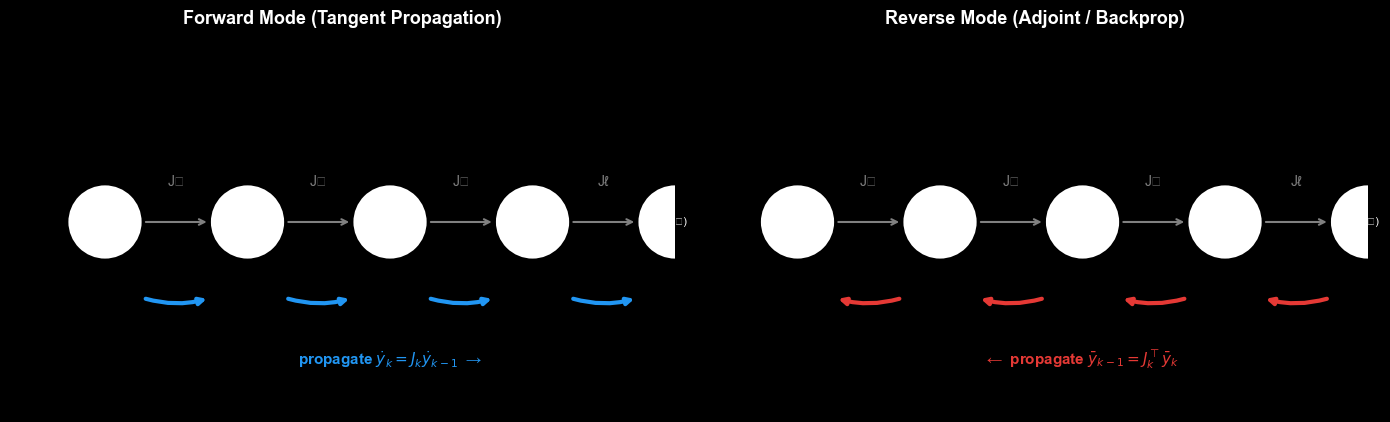

Saved forward_vs_reverse_ad.png ✓


In [15]:
# --- 3.6  Visualisation: computational graph with forward & reverse annotations ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title, color_fwd, color_rev, mode in [
    (axes[0], "Forward Mode (Tangent Propagation)", "#2196F3", "#BBDEFB", "forward"),
    (axes[1], "Reverse Mode (Adjoint / Backprop)", "#BBDEFB", "#E53935", "reverse"),
]:
    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(-1.5, 2.5)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold")

    # Nodes
    node_x = [0.5, 2.0, 3.5, 5.0, 6.5]
    node_labels = ["x", "y₁=f₁(x)", "y₂=f₂(y₁)", "y₃=f₃(y₂)", "ℓ(y₃)"]
    jac_labels = ["J₁", "J₂", "J₃", "Jℓ"]

    for i, (nx, label) in enumerate(zip(node_x, node_labels)):
        circ = plt.Circle((nx, 0.5), 0.4, fc="white", ec="black", lw=2, zorder=5)
        ax.add_patch(circ)
        ax.text(nx, 0.5, label, ha="center", va="center", fontsize=8, zorder=6)

    # Edges + Jacobian labels
    for i in range(4):
        x_start = node_x[i] + 0.4
        x_end   = node_x[i+1] - 0.4
        ax.annotate("", xy=(x_end, 0.5), xytext=(x_start, 0.5),
                     arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
        ax.text((x_start+x_end)/2, 0.85, jac_labels[i],
                ha="center", va="bottom", fontsize=10, color="gray")

    # Propagation arrows
    if mode == "forward":
        for i in range(4):
            x_s = node_x[i] + 0.4
            x_e = node_x[i+1] - 0.4
            ax.annotate("", xy=(x_e, -0.3), xytext=(x_s, -0.3),
                         arrowprops=dict(arrowstyle="-|>", color=color_fwd,
                                         lw=3, connectionstyle="arc3,rad=0.15"))
        ax.text(3.5, -1.0, r"propagate $\dot{y}_k = J_k \dot{y}_{k-1}$  →",
                ha="center", fontsize=11, color=color_fwd, fontweight="bold")
    else:
        for i in range(3, -1, -1):
            x_s = node_x[i+1] - 0.4
            x_e = node_x[i] + 0.4
            ax.annotate("", xy=(x_e, -0.3), xytext=(x_s, -0.3),
                         arrowprops=dict(arrowstyle="-|>", color=color_rev,
                                         lw=3, connectionstyle="arc3,rad=-0.15"))
        ax.text(3.5, -1.0, r"←  propagate $\bar{y}_{k-1} = J_k^\top \bar{y}_k$",
                ha="center", fontsize=11, color=color_rev, fontweight="bold")

plt.tight_layout()
plt.savefig("forward_vs_reverse_ad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved forward_vs_reverse_ad.png ✓")

# 4. Derivatives of Matrix Determinants and Inverses

> *"The determinant is the volume; its derivative tells you how volume breathes."*

---

## 4.1 The Determinant as a Scalar Function of a Matrix

The determinant maps square matrices to scalars:

$$\det : \mathbb{R}^{n\times n} \;\longrightarrow\; \mathbb{R}$$

We want its **Fréchet derivative** — the linear map $L$ such that

$$\det(A + \delta A) = \det(A) + L(\delta A) + o(\|\delta A\|).$$

### Derivation via the Fréchet approach

For invertible $A$:

$$\det(A + \delta A) = \det(A)\,\det\!\bigl(I + A^{-1}\delta A\bigr).$$

Using the first-order expansion $\det(I + \varepsilon B) \approx 1 + \varepsilon\,\mathrm{tr}(B) + O(\varepsilon^2)$:

$$\boxed{d(\det A) = \det(A)\;\mathrm{tr}\!\bigl(A^{-1}\,dA\bigr).}$$

Writing this as a **gradient** (matrix of partial derivatives):

$$\nabla_A(\det A) = \det(A)\;A^{-\!\top}
\;=\; \mathrm{cof}(A)^{\!\top} \;=\; \mathrm{adj}(A)^{\!\top}.$$

---

## 4.2 Derivative of $\log\det A$

Since $d(\log u) = du/u$:

$$d(\log\det A) = \frac{\det(A)\;\mathrm{tr}(A^{-1}\,dA)}{\det(A)}
= \mathrm{tr}\!\bigl(A^{-1}\,dA\bigr).$$

$$\boxed{\nabla_A\!\bigl(\log\det A\bigr) = A^{-\!\top}.}$$

This is **ubiquitous**:
- **Gaussian log-likelihood**: $\log p(\mathbf x) \propto -\tfrac12 \log\det\Sigma$
- **Information geometry**: the Fisher metric involves $\partial_\theta \log\det \Sigma$
- **Bayesian inference**: marginal likelihoods require $\log\det$ terms

---

## 4.3 Derivative of the Matrix Inverse (Revisited)

Starting from $A A^{-1} = I$ and differentiating both sides:

$$dA\;A^{-1} + A\;d(A^{-1}) = 0
\quad\Longrightarrow\quad
\boxed{d(A^{-1}) = -A^{-1}\,(dA)\,A^{-1}.}$$

**Second derivative** (applying the product rule twice):

$$d^2(A^{-1}) = A^{-1}(dA)\,A^{-1}(dA)\,A^{-1}
+ A^{-1}(dA)\,A^{-1}(dA)\,A^{-1}
= 2\,A^{-1}(dA)\,A^{-1}(dA)\,A^{-1}.$$

(Two ways to insert two $dA$ perturbations.)

---

## 4.4 Application — Newton's Method for Eigenvalues via $\det(A-\lambda I)=0$

The eigenvalues of $A$ are the roots of $p(\lambda) = \det(A - \lambda I)$.

Using our determinant derivative:

$$\frac{\partial}{\partial\lambda}\det(A - \lambda I)
= \det(A-\lambda I)\;\mathrm{tr}\!\bigl((A-\lambda I)^{-1}\cdot(-I)\bigr)
= -\det(A-\lambda I)\;\mathrm{tr}\!\bigl((A-\lambda I)^{-1}\bigr).$$

Newton's update:

$$\lambda_{k+1} = \lambda_k
- \frac{\det(A - \lambda_k I)}{-\det(A-\lambda_k I)\;\mathrm{tr}((A-\lambda_k I)^{-1})}
= \lambda_k + \frac{1}{\mathrm{tr}\!\bigl((A-\lambda_k I)^{-1}\bigr)}.$$

---

## 💡 Physicist's Intuition

| Quantity | Physical meaning |
|---|---|
| $\det(A)$ | Volume scaling factor of the linear map $A$ |
| $\log\det(A)$ | Entropy of a Gaussian $\mathcal{N}(0, A)$ (up to constants) |
| $\mathrm{tr}(A^{-1}\,dA)$ | Relative (infinitesimal) volume change |

In [16]:
# 4.1 — Verify ∇(det A) = det(A) · A⁻ᵀ  via finite differences
np.random.seed(42)
A = np.random.randn(3, 3)

# Analytical gradient
det_A = np.linalg.det(A)
grad_analytical = det_A * np.linalg.inv(A).T

# Finite-difference gradient (central)
h = 1e-7
grad_fd = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        E = np.zeros_like(A)
        E[i, j] = h
        grad_fd[i, j] = (np.linalg.det(A + E) - np.linalg.det(A - E)) / (2 * h)

rel_err = np.linalg.norm(grad_analytical - grad_fd) / np.linalg.norm(grad_analytical)
print("∇(det A) verification")
print(f"  Analytical:\n{grad_analytical}")
print(f"  Finite-diff:\n{grad_fd}")
print(f"  Relative error: {rel_err:.2e}  ✅" if rel_err < 1e-5 else f"  Relative error: {rel_err:.2e}  ❌")

∇(det A) verification
  Analytical:
[[ 0.289614  0.345271  1.538604]
 [ 0.432147 -1.256033 -0.599544]
 [ 0.184031  1.102748  0.094273]]
  Finite-diff:
[[ 0.289614  0.345271  1.538604]
 [ 0.432147 -1.256033 -0.599544]
 [ 0.184031  1.102748  0.094273]]
  Relative error: 1.11e-09  ✅


In [17]:
# 4.2 — Verify ∇(log det A) = A⁻ᵀ  via finite differences
np.random.seed(7)
A = np.random.randn(4, 4)
A = A @ A.T + np.eye(4)  # SPD so log det is real

grad_analytical = np.linalg.inv(A).T

h = 1e-7
grad_fd = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        E = np.zeros_like(A)
        E[i, j] = h
        f_plus  = np.log(np.linalg.det(A + E))
        f_minus = np.log(np.linalg.det(A - E))
        grad_fd[i, j] = (f_plus - f_minus) / (2 * h)

rel_err = np.linalg.norm(grad_analytical - grad_fd) / np.linalg.norm(grad_analytical)
print("∇(log det A) verification")
print(f"  Relative error: {rel_err:.2e}  ✅" if rel_err < 1e-5 else f"  Relative error: {rel_err:.2e}  ❌")

∇(log det A) verification
  Relative error: 9.98e-09  ✅


In [18]:
# 4.3 — Verify d(A⁻¹) = -A⁻¹ (dA) A⁻¹  numerically
np.random.seed(99)
A = np.random.randn(4, 4)
A = A + 3 * np.eye(4)  # ensure invertible
dA = np.random.randn(4, 4) * 0.001  # small perturbation

Ainv = np.linalg.inv(A)

# Analytical first-order change
dAinv_analytical = -Ainv @ dA @ Ainv

# Numerical change
Ainv_pert = np.linalg.inv(A + dA)
dAinv_numerical = Ainv_pert - Ainv

rel_err = np.linalg.norm(dAinv_analytical - dAinv_numerical) / np.linalg.norm(dAinv_numerical)
print("d(A⁻¹) = -A⁻¹(dA)A⁻¹ verification")
print(f"  ‖analytical - numerical‖ / ‖numerical‖ = {rel_err:.2e}")
print(f"  (Small because dA is small → first-order approx is accurate)  ✅" if rel_err < 1e-2 else "  ❌")

d(A⁻¹) = -A⁻¹(dA)A⁻¹ verification
  ‖analytical - numerical‖ / ‖numerical‖ = 4.98e-04
  (Small because dA is small → first-order approx is accurate)  ✅


In [19]:
# 4.4 — Newton's method for eigenvalues via det(A - λI) = 0
np.random.seed(12)
B = np.random.randn(3, 3)
A = (B + B.T) / 2  # symmetric → real eigenvalues

def newton_eigenvalue(A, lam0, tol=1e-12, max_iter=50):
    '''Newton iteration: lam_{k+1} = lam_k + 1 / tr((A - lam_k I)^{-1}).'''
    lam = lam0
    n = A.shape[0]
    for k in range(max_iter):
        M = A - lam * np.eye(n)
        try:
            Minv = np.linalg.inv(M)
        except np.linalg.LinAlgError:
            break  # converged (M is singular → λ is eigenvalue)
        update = 1.0 / np.trace(Minv)
        lam = lam + update
        if abs(update) < tol:
            break
    return lam

# True eigenvalues
eigs_true = np.sort(np.linalg.eigvalsh(A))
print("True eigenvalues:", eigs_true)

# Newton from different starting points
starts = [-3.0, 0.0, 3.0]
newton_eigs = sorted([newton_eigenvalue(A, s) for s in starts])
print("Newton eigenvalues:", [f"{e:.10f}" for e in newton_eigs])

for ne in newton_eigs:
    closest = eigs_true[np.argmin(np.abs(eigs_true - ne))]
    err = abs(ne - closest)
    tag = "✅" if err < 1e-8 else "❌"
    print(f"  Newton {ne:.10f}  vs  true {closest:.10f}  |err|={err:.2e} {tag}")

True eigenvalues: [-1.271448 -0.302296  1.992891]
Newton eigenvalues: ['-1.2714484802', '-0.3022958304', '1.9928910975']
  Newton -1.2714484802  vs  true -1.2714484802  |err|=0.00e+00 ✅
  Newton -0.3022958304  vs  true -0.3022958304  |err|=1.11e-16 ✅
  Newton 1.9928910975  vs  true 1.9928910975  |err|=2.22e-16 ✅


In [20]:
# 4.5 — Compare Newton eigenvalues with np.linalg.eigvalsh on a larger matrix
np.random.seed(55)
n = 5
B = np.random.randn(n, n)
A = (B + B.T) / 2

eigs_true = np.sort(np.linalg.eigvalsh(A))

# Use many starting points to find all eigenvalues
starts = np.linspace(eigs_true[0] - 1, eigs_true[-1] + 1, 20)
newton_raw = [newton_eigenvalue(A, s) for s in starts]

# Cluster nearby results
newton_unique = []
for e in sorted(newton_raw):
    if not newton_unique or abs(e - newton_unique[-1]) > 1e-6:
        newton_unique.append(e)

print(f"{'Newton':>14s}   {'np.eigvalsh':>14s}   {'|error|':>10s}")
print("-" * 46)
for ne in newton_unique[:n]:
    closest = eigs_true[np.argmin(np.abs(eigs_true - ne))]
    print(f"{ne:14.10f}   {closest:14.10f}   {abs(ne-closest):10.2e}")

        Newton      np.eigvalsh      |error|
----------------------------------------------
 -2.2333632801    -2.2333632801     4.44e-16
 -0.4608141144    -0.4608141144     1.11e-16
  0.7145375382     0.7145375382     0.00e+00
  0.8809990364     0.8809990364     0.00e+00
  2.3244885899     2.3244885899     4.44e-16


# 5. Finite-Difference Methods & Numerical Verification

> *"If you can't check it numerically, you don't really know it."*

---

## 5.1 The Three Approximations

| Method | Formula | Error |
|---|---|---|
| **Forward** | $f'(x) \approx \dfrac{f(x+h) - f(x)}{h}$ | $O(h)$ |
| **Central** | $f'(x) \approx \dfrac{f(x+h) - f(x-h)}{2h}$ | $O(h^2)$ |
| **Complex-step** | $f'(x) = \dfrac{\mathrm{Im}[f(x + ih)]}{h}$ | $O(h^2)$, **no cancellation!** |

### Why the complex-step method is magical

$$f(x + ih) = f(x) + ih\,f'(x) - \frac{h^2}{2}f''(x) - \cdots$$

$$\Rightarrow\quad \frac{\mathrm{Im}[f(x+ih)]}{h} = f'(x) + O(h^2)$$

There is **no subtraction of nearly-equal numbers**, so roundoff error does not grow as $h\to 0$.

---

## 5.2 The Two Sources of Error

Every finite-difference approximation suffers from two competing errors:

1. **Truncation error** — from dropping higher-order Taylor terms.
   Decreases as $h \to 0$.

2. **Roundoff error** — from floating-point cancellation in the numerator
   $f(x+h) - f(x)$. **Increases** as $h \to 0$ (catastrophic cancellation).

### Optimal step size

| Method | Truncation | Roundoff | Optimal $h$ |
|---|---|---|---|
| Forward | $O(h)$ | $O(\varepsilon_{\mathrm{mach}}/h)$ | $h \approx \sqrt{\varepsilon_{\mathrm{mach}}} \approx 1.5\times10^{-8}$ |
| Central | $O(h^2)$ | $O(\varepsilon_{\mathrm{mach}}/h)$ | $h \approx \varepsilon_{\mathrm{mach}}^{1/3} \approx 6\times10^{-6}$ |
| Complex-step | $O(h^2)$ | **none** | As small as you like! |

---

## 5.3 Richardson Extrapolation

If $D(h)$ is a central-difference estimate with error $O(h^2)$:

$$D_{\text{rich}}(h) = \frac{4\,D(h/2) - D(h)}{3}$$

cancels the $O(h^2)$ term, giving $O(h^4)$ accuracy.
This can be applied **recursively** (Romberg-like) to achieve arbitrarily high order.

---

## 5.4 Building a Robust Gradient Checker

For **matrix-input** scalar functions $f: \mathbb{R}^{m\times n}\to\mathbb{R}$:

1. Use **central differences** with $h \approx 10^{-5}$.
2. Perturb each element $A_{ij}$ independently.
3. Compute **relative error** per component:
$$\text{rel\_err}_{ij} = \frac{|g^{\text{anal}}_{ij} - g^{\text{fd}}_{ij}|}
{\max(|g^{\text{anal}}_{ij}|,\;|g^{\text{fd}}_{ij}|,\;\varepsilon)}$$
4. Threshold: relative error $< 10^{-5}$ is good; $< 10^{-7}$ is excellent.

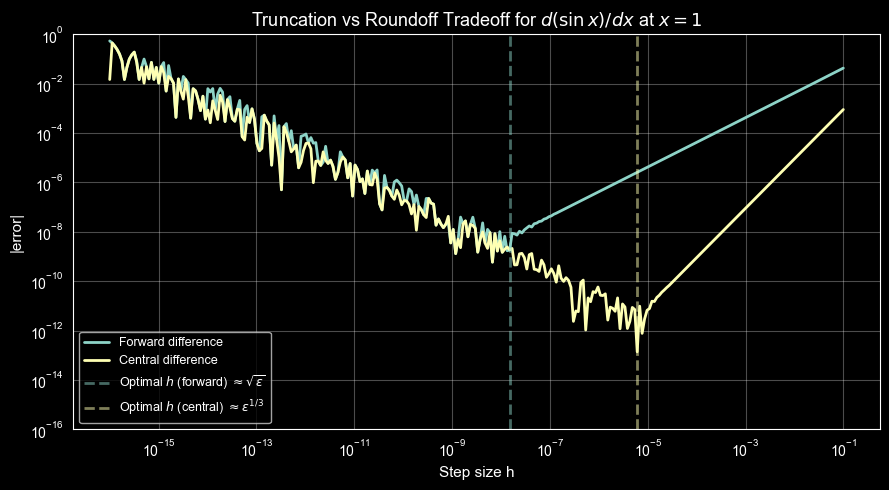

Saved fd_tradeoff.png


In [21]:
# 5.1 — Truncation vs roundoff tradeoff
x0 = 1.0
true_deriv = np.cos(x0)  # derivative of sin(x)

hs = np.logspace(-1, -16, 300)
err_fwd = np.zeros_like(hs)
err_cen = np.zeros_like(hs)

for k, h in enumerate(hs):
    fwd = (np.sin(x0 + h) - np.sin(x0)) / h
    cen = (np.sin(x0 + h) - np.sin(x0 - h)) / (2 * h)
    err_fwd[k] = abs(fwd - true_deriv)
    err_cen[k] = abs(cen - true_deriv)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(hs, err_fwd, label="Forward difference", lw=2)
ax.loglog(hs, err_cen, label="Central difference", lw=2)
ax.axvline(1.5e-8, color="C0", ls="--", alpha=0.5, label=r"Optimal $h$ (forward) $\approx\sqrt{\epsilon}$")
ax.axvline(6e-6,  color="C1", ls="--", alpha=0.5, label=r"Optimal $h$ (central) $\approx\epsilon^{1/3}$")
ax.set_xlabel("Step size h")
ax.set_ylabel("|error|")
ax.set_title(r"Truncation vs Roundoff Tradeoff for $d(\sin x)/dx$ at $x=1$")
ax.legend(fontsize=9)
ax.set_ylim(1e-16, 1)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fd_tradeoff.png", dpi=120)
plt.show()
print("Saved fd_tradeoff.png")

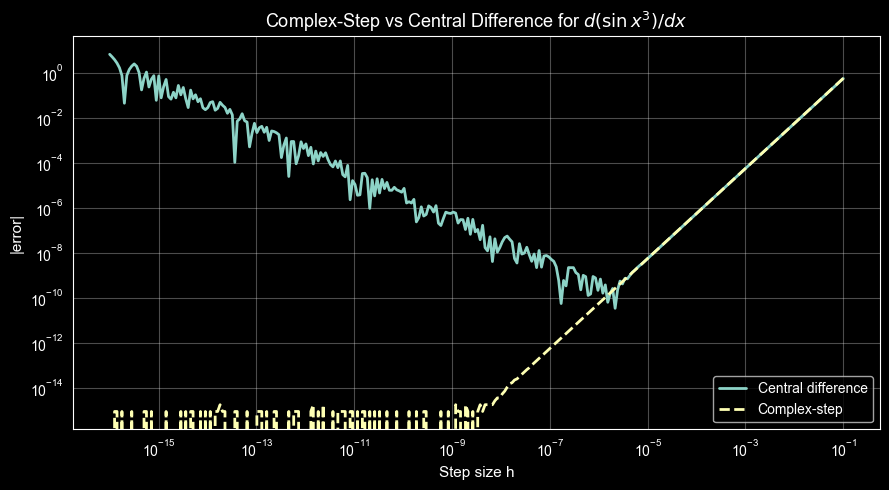

Complex-step maintains accuracy even at h = 1e-16!


In [22]:
# 5.2 — Complex-step derivative: works at tiny h where FD fails
x0 = 1.5
true_deriv = 3 * x0**2 * np.cos(x0**3)  # d/dx sin(x³)

hs = np.logspace(-1, -16, 300)
err_cen  = np.zeros_like(hs)
err_cpx  = np.zeros_like(hs)

f = lambda x: np.sin(x**3)

for k, h in enumerate(hs):
    cen = (f(x0 + h) - f(x0 - h)) / (2 * h)
    cpx = np.imag(f(x0 + 1j * h)) / h
    err_cen[k] = abs(cen - true_deriv)
    err_cpx[k] = abs(cpx - true_deriv)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(hs, err_cen, label="Central difference", lw=2)
ax.loglog(hs, err_cpx, label="Complex-step", lw=2, ls="--")
ax.set_xlabel("Step size h")
ax.set_ylabel("|error|")
ax.set_title(r"Complex-Step vs Central Difference for $d(\sin x^3)/dx$")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("complex_step.png", dpi=120)
plt.show()
print("Complex-step maintains accuracy even at h = 1e-16!")

/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/2734377626.py:34: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/2734377626.py:34: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/2734377626.py:35: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Arial.
  plt.savefig("richardson.png", dpi=120)
/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_66871/2734377626.py:35: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  plt.savefig("richardson.png", dpi=120)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Framewor

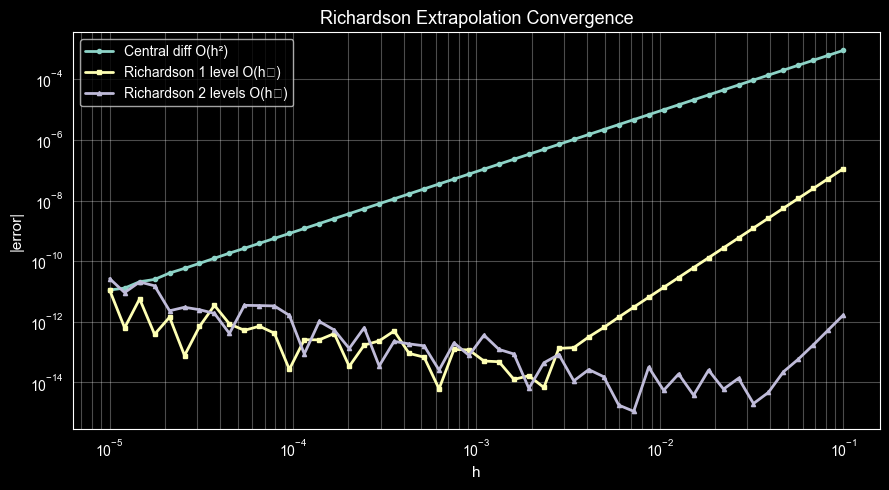

Richardson extrapolation dramatically improves convergence rate.


In [23]:
# 5.3 — Richardson extrapolation for improved convergence
x0 = 1.0
true_deriv = np.cos(x0)

def central_diff(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

def richardson(f, x, h):
    '''One level of Richardson: cancels O(h^2) -> O(h^4).'''
    D_h  = central_diff(f, x, h)
    D_h2 = central_diff(f, x, h / 2)
    return (4 * D_h2 - D_h) / 3

def richardson2(f, x, h):
    '''Two levels of Richardson: O(h^6).'''
    R_h  = richardson(f, x, h)
    R_h2 = richardson(f, x, h / 2)
    return (16 * R_h2 - R_h) / 15

hs = np.logspace(-1, -5, 50)
err_cen  = [abs(central_diff(np.sin, x0, h) - true_deriv) for h in hs]
err_r1   = [abs(richardson(np.sin, x0, h) - true_deriv) for h in hs]
err_r2   = [abs(richardson2(np.sin, x0, h) - true_deriv) for h in hs]

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(hs, err_cen, "o-", ms=3, label="Central diff O(h²)")
ax.loglog(hs, err_r1,  "s-", ms=3, label="Richardson 1 level O(h⁴)")
ax.loglog(hs, err_r2,  "^-", ms=3, label="Richardson 2 levels O(h⁶)")
ax.set_xlabel("h")
ax.set_ylabel("|error|")
ax.set_title("Richardson Extrapolation Convergence")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("richardson.png", dpi=120)
plt.show()
print("Richardson extrapolation dramatically improves convergence rate.")

In [24]:
# 5.4 — Robust gradient checker for vector-input scalar functions
def check_gradient(f, grad_f, x, h=1e-5, tol=1e-5):
    '''
    Check analytical gradient against central finite differences.

    Parameters
    ----------
    f      : callable, f(x) -> scalar
    grad_f : callable, grad_f(x) -> array same shape as x
    x      : ndarray, point at which to check
    h      : float, step size for central differences
    tol    : float, relative error threshold

    Returns
    -------
    passed : bool
    info   : dict with details
    '''
    x = np.asarray(x, dtype=float)
    g_anal = np.asarray(grad_f(x), dtype=float)
    g_fd   = np.zeros_like(x)

    for idx in np.ndindex(x.shape):
        e = np.zeros_like(x)
        e[idx] = h
        g_fd[idx] = (f(x + e) - f(x - e)) / (2 * h)

    eps = 1e-12
    rel_err = np.abs(g_anal - g_fd) / np.maximum(np.maximum(np.abs(g_anal), np.abs(g_fd)), eps)
    max_rel_err = np.max(rel_err)
    passed = max_rel_err < tol

    return passed, {"max_rel_error": max_rel_err, "analytical": g_anal, "numerical": g_fd}

# Test on f(x) = x' A x
np.random.seed(0)
n = 4
M = np.random.randn(n, n)
A_sym = (M + M.T) / 2

f  = lambda x: x @ A_sym @ x
gf = lambda x: 2 * A_sym @ x

x0 = np.random.randn(n)
ok, info = check_gradient(f, gf, x0)
print(f"f(x) = x'Ax:  passed={ok}, max_rel_err={info['max_rel_error']:.2e}")

f(x) = x'Ax:  passed=True, max_rel_err=7.79e-11


In [25]:
# 5.5 — Robust gradient checker for matrix-input scalar functions
def check_matrix_gradient(f, grad_f, A, h=1e-5, tol=1e-5):
    '''
    Check analytical gradient of f: R^{mxn} -> R against central differences.
    '''
    A = np.asarray(A, dtype=float)
    g_anal = np.asarray(grad_f(A), dtype=float)
    g_fd   = np.zeros_like(A)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            E = np.zeros_like(A)
            E[i, j] = h
            g_fd[i, j] = (f(A + E) - f(A - E)) / (2 * h)

    eps = 1e-12
    rel_err = np.abs(g_anal - g_fd) / np.maximum(np.maximum(np.abs(g_anal), np.abs(g_fd)), eps)
    max_rel_err = np.max(rel_err)
    passed = max_rel_err < tol

    return passed, {"max_rel_error": max_rel_err}

print("check_matrix_gradient defined ✅")

check_matrix_gradient defined ✅


In [26]:
# 5.6 — Demonstrate gradient checkers on det(A), log det(A), tr(A²), x'Ax
np.random.seed(42)
n = 3
B = np.random.randn(n, n)
A = B @ B.T + np.eye(n)  # SPD

tests = {
    "det(A)": (
        lambda A: np.linalg.det(A),
        lambda A: np.linalg.det(A) * np.linalg.inv(A).T,
    ),
    "log det(A)": (
        lambda A: np.log(np.linalg.det(A)),
        lambda A: np.linalg.inv(A).T,
    ),
    "tr(A²)": (
        lambda A: np.trace(A @ A),
        lambda A: 2 * A.T,
    ),
    "tr(A³)": (
        lambda A: np.trace(A @ A @ A),
        lambda A: 3 * (A @ A).T,
    ),
}

print(f"{'Function':>15s}   {'Passed':>6s}   {'Max Rel Err':>12s}")
print("-" * 42)
for name, (f, gf) in tests.items():
    ok, info = check_matrix_gradient(f, gf, A)
    tag = "✅" if ok else "❌"
    print(f"{name:>15s}   {str(ok):>6s}   {info['max_rel_error']:12.2e}  {tag}")

# Also test x'Ax
x0 = np.random.randn(n)
ok, info = check_gradient(lambda x: x @ A @ x, lambda x: (A + A.T) @ x, x0)
label = "x'Ax"
print(f"{label:>15s}   {str(ok):>6s}   {info['max_rel_error']:12.2e}  {'✅' if ok else '❌'}")

       Function   Passed    Max Rel Err
------------------------------------------
         det(A)     True       1.93e-09  ✅
     log det(A)     True       1.82e-09  ✅
         tr(A²)     True       3.17e-10  ✅
         tr(A³)     True       2.02e-10  ✅
           x'Ax     True       5.80e-12  ✅


# 6. Automatic Differentiation (AD)

> *"AD is neither symbolic nor numerical — it is exact and efficient."*

---

## 6.1 Why AD?

| Method | Pros | Cons |
|---|---|---|
| **Symbolic** | Exact formulas | Expression swell (exponentially large) |
| **Finite diff** | Easy to implement | Approximate; truncation + roundoff |
| **AD** | Exact to machine precision, efficient | Requires implementation overhead |

---

## 6.2 Forward-Mode AD via Dual Numbers

Define a **dual number**: $a + b\varepsilon$ where $\varepsilon^2 = 0$ (nilpotent).

**Arithmetic rules**:

$$
(a + b\varepsilon) + (c + d\varepsilon) = (a+c) + (b+d)\varepsilon
$$
$$
(a + b\varepsilon)(c + d\varepsilon) = ac + (ad + bc)\varepsilon
\quad(\text{since } \varepsilon^2 = 0)
$$

**Key insight**: evaluate $f(a + \varepsilon)$ and the $\varepsilon$-coefficient gives $f'(a)$:

$$f(a + b\varepsilon) = f(a) + f'(a)\,b\,\varepsilon$$

Examples:
- $\sin(a + b\varepsilon) = \sin a + (\cos a)\,b\,\varepsilon$
- $\exp(a + b\varepsilon) = e^a + e^a\,b\,\varepsilon$
- $(a + b\varepsilon)^{-1} = a^{-1} - a^{-2}\,b\,\varepsilon$

---

## 6.3 Reverse-Mode AD (Backpropagation)

1. **Forward pass**: evaluate $f$, recording all operations on a "tape" (computational graph).
2. **Backward pass**: traverse the tape in reverse, propagating **adjoints** $\bar{v}_i = \partial f/\partial v_i$ using the chain rule.

**Cost**: One forward + one backward pass computes the **full gradient** $\nabla f \in \mathbb{R}^n$
regardless of $n$. (Forward-mode would need $n$ passes.)

---

## 6.4 Forward-over-Reverse for Hessians

Apply **forward-mode** (dual numbers) to the **reverse-mode gradient** computation:

- Seed a direction $v$, let each input $x_i$ become $x_i + v_i\varepsilon$.
- Run the reverse-mode backward pass with dual-number arithmetic.
- The $\varepsilon$-coefficients of the gradient give $Hv$ (Hessian-vector product).
- Cost: $O(1)$ forward + backward passes per Hessian column.

---

## 💡 Physicist's Intuition

Dual numbers with $\varepsilon^2 = 0$ are the same algebraic structure as:
- **Grassmann numbers** in supersymmetry / path integrals
- **Infinitesimals** in nonstandard analysis (Robinson, 1960s)
- **Jet spaces** in differential geometry

They make "infinitesimal perturbation" a **first-class algebraic object**.

In [27]:
# 6.1 — Dual Number class for forward-mode AD
class DualNumber:
    '''Dual number a + b*eps where eps^2 = 0.'''
    __slots__ = ("val", "der")

    def __init__(self, val, der=0.0):
        self.val = float(val)
        self.der = float(der)

    def __repr__(self):
        return f"Dual({self.val:.6g} + {self.der:.6g}ε)"

    # --- arithmetic ---
    def __add__(self, other):
        if not isinstance(other, DualNumber):
            other = DualNumber(other)
        return DualNumber(self.val + other.val, self.der + other.der)

    def __radd__(self, other):
        return self.__add__(other)

    def __sub__(self, other):
        if not isinstance(other, DualNumber):
            other = DualNumber(other)
        return DualNumber(self.val - other.val, self.der - other.der)

    def __rsub__(self, other):
        if not isinstance(other, DualNumber):
            other = DualNumber(other)
        return DualNumber(other.val - self.val, other.der - self.der)

    def __mul__(self, other):
        if not isinstance(other, DualNumber):
            other = DualNumber(other)
        return DualNumber(self.val * other.val,
                          self.val * other.der + self.der * other.val)

    def __rmul__(self, other):
        return self.__mul__(other)

    def __truediv__(self, other):
        if not isinstance(other, DualNumber):
            other = DualNumber(other)
        inv_val = 1.0 / other.val
        return DualNumber(self.val * inv_val,
                          (self.der * other.val - self.val * other.der) * inv_val**2)

    def __rtruediv__(self, other):
        if not isinstance(other, DualNumber):
            other = DualNumber(other)
        return other.__truediv__(self)

    def __pow__(self, n):
        if isinstance(n, DualNumber):
            # general: a^b = exp(b ln a)
            return dual_exp(n * dual_log(self))
        return DualNumber(self.val ** n,
                          n * self.val ** (n - 1) * self.der)

    def __rpow__(self, base):
        # base ** self  where base is a plain number
        base_d = DualNumber(base)
        return dual_exp(self * dual_log(base_d))

    def __neg__(self):
        return DualNumber(-self.val, -self.der)

print("DualNumber class defined ✅")
print(DualNumber(3, 1))

DualNumber class defined ✅
Dual(3 + 1ε)


In [28]:
# 6.2 — Math functions for dual numbers
def dual_sin(d):
    return DualNumber(np.sin(d.val), np.cos(d.val) * d.der)

def dual_cos(d):
    return DualNumber(np.cos(d.val), -np.sin(d.val) * d.der)

def dual_exp(d):
    ev = np.exp(d.val)
    return DualNumber(ev, ev * d.der)

def dual_log(d):
    return DualNumber(np.log(d.val), d.der / d.val)

# Quick test
x = DualNumber(np.pi / 4, 1.0)  # seed der=1 → computing d/dx at x=π/4
print(f"sin(π/4) = {dual_sin(x)}")
print(f"  value = {np.sin(np.pi/4):.6f}, deriv should be cos(π/4) = {np.cos(np.pi/4):.6f}")
print(f"exp(π/4) = {dual_exp(x)}")
print(f"  value = {np.exp(np.pi/4):.6f}, deriv should be exp(π/4) = {np.exp(np.pi/4):.6f}")
print("Dual math functions ✅")

sin(π/4) = Dual(0.707107 + 0.707107ε)
  value = 0.707107, deriv should be cos(π/4) = 0.707107
exp(π/4) = Dual(2.19328 + 2.19328ε)
  value = 2.193280, deriv should be exp(π/4) = 2.193280
Dual math functions ✅


In [29]:
# 6.3 — Derivative of f(x) = sin(x²) + exp(x) at x=1.5 using dual numbers
x0 = 1.5

# Dual number evaluation
x_dual = DualNumber(x0, 1.0)
result = dual_sin(x_dual ** 2) + dual_exp(x_dual)

# Analytical derivative: 2x cos(x²) + exp(x)
deriv_analytical = 2 * x0 * np.cos(x0**2) + np.exp(x0)

# Finite-difference check
h = 1e-8
f = lambda x: np.sin(x**2) + np.exp(x)
deriv_fd = (f(x0 + h) - f(x0 - h)) / (2 * h)

print(f"f(x) = sin(x²) + exp(x) at x = {x0}")
print(f"  Dual number derivative:  {result.der:.12f}")
print(f"  Analytical derivative:   {deriv_analytical:.12f}")
print(f"  Finite-diff derivative:  {deriv_fd:.12f}")
print(f"  |dual - analytical|:     {abs(result.der - deriv_analytical):.2e}")
print(f"  |FD   - analytical|:     {abs(deriv_fd - deriv_analytical):.2e}")
print("  Dual numbers give machine-precision accuracy ✅")

f(x) = sin(x²) + exp(x) at x = 1.5
  Dual number derivative:  2.597168202170
  Analytical derivative:   2.597168202170
  Finite-diff derivative:  2.597168169416
  |dual - analytical|:     0.00e+00
  |FD   - analytical|:     3.28e-08
  Dual numbers give machine-precision accuracy ✅


In [30]:
# 6.4 — Simple reverse-mode AD (backpropagation)

class Variable:
    '''Node in a computational graph supporting reverse-mode AD.'''

    def __init__(self, val, children=(), backward_fn=None, name=""):
        self.val = float(val)
        self.grad = 0.0
        self.children = children
        self.backward_fn = backward_fn
        self.name = name

    def backward(self, seed=1.0):
        '''Backpropagate gradient through the computational graph.'''
        # topological sort
        topo_order = []
        visited = set()
        def build(node):
            if id(node) not in visited:
                visited.add(id(node))
                for c in node.children:
                    build(c)
                topo_order.append(node)
        build(self)

        # reset grads
        for node in topo_order:
            node.grad = 0.0
        self.grad = seed

        # backward pass
        for node in reversed(topo_order):
            if node.backward_fn is not None:
                node.backward_fn(node.grad)

    def __repr__(self):
        return f"Var({self.val:.6g}, grad={self.grad:.6g})"

    def __add__(self, other):
        if not isinstance(other, Variable):
            other = Variable(other)
        out = Variable(self.val + other.val, children=(self, other))
        def _backward(g):
            self.grad  += g
            other.grad += g
        out.backward_fn = _backward
        return out

    def __radd__(self, other):
        return self.__add__(other)

    def __mul__(self, other):
        if not isinstance(other, Variable):
            other = Variable(other)
        out = Variable(self.val * other.val, children=(self, other))
        def _backward(g):
            self.grad  += g * other.val
            other.grad += g * self.val
        out.backward_fn = _backward
        return out

    def __rmul__(self, other):
        return self.__mul__(other)

    def __sub__(self, other):
        if not isinstance(other, Variable):
            other = Variable(other)
        out = Variable(self.val - other.val, children=(self, other))
        def _backward(g):
            self.grad  += g
            other.grad -= g
        out.backward_fn = _backward
        return out

    def __rsub__(self, other):
        if not isinstance(other, Variable):
            other = Variable(other)
        return other.__sub__(self)

    def __pow__(self, n):
        out = Variable(self.val ** n, children=(self,))
        def _backward(g):
            self.grad += g * n * self.val ** (n - 1)
        out.backward_fn = _backward
        return out

    def __neg__(self):
        return self * (-1)

def var_sin(v):
    out = Variable(np.sin(v.val), children=(v,))
    def _backward(g):
        v.grad += g * np.cos(v.val)
    out.backward_fn = _backward
    return out

def var_cos(v):
    out = Variable(np.cos(v.val), children=(v,))
    def _backward(g):
        v.grad += g * (-np.sin(v.val))
    out.backward_fn = _backward
    return out

def var_exp(v):
    ev = np.exp(v.val)
    out = Variable(ev, children=(v,))
    def _backward(g):
        v.grad += g * ev
    out.backward_fn = _backward
    return out

def var_log(v):
    out = Variable(np.log(v.val), children=(v,))
    def _backward(g):
        v.grad += g / v.val
    out.backward_fn = _backward
    return out

print("Reverse-mode AD (Variable class) defined ✅")

Reverse-mode AD (Variable class) defined ✅


In [31]:
# 6.5 — Test reverse-mode: f(x,y) = sin(xy) + x²y
x0, y0 = 2.0, 3.0

x = Variable(x0, name="x")
y = Variable(y0, name="y")

f = var_sin(x * y) + x**2 * y
f.backward()

# Analytical gradients
# df/dx = y cos(xy) + 2xy
# df/dy = x cos(xy) + x²
dfdx_anal = y0 * np.cos(x0 * y0) + 2 * x0 * y0
dfdy_anal = x0 * np.cos(x0 * y0) + x0**2

# Finite-difference check
h = 1e-7
ff = lambda xx, yy: np.sin(xx * yy) + xx**2 * yy
dfdx_fd = (ff(x0 + h, y0) - ff(x0 - h, y0)) / (2 * h)
dfdy_fd = (ff(x0, y0 + h) - ff(x0, y0 - h)) / (2 * h)

print(f"f(x,y) = sin(xy) + x²y  at ({x0}, {y0})")
print(f"  ∂f/∂x:  reverse-AD = {x.grad:.10f}  analytical = {dfdx_anal:.10f}  FD = {dfdx_fd:.10f}")
print(f"  ∂f/∂y:  reverse-AD = {y.grad:.10f}  analytical = {dfdy_anal:.10f}  FD = {dfdy_fd:.10f}")
print(f"  |AD - analytical| (x): {abs(x.grad - dfdx_anal):.2e}")
print(f"  |AD - analytical| (y): {abs(y.grad - dfdy_anal):.2e}")
print("  Reverse-mode AD ✅" if abs(x.grad - dfdx_anal) < 1e-10 and abs(y.grad - dfdy_anal) < 1e-10 else "  ❌")

f(x,y) = sin(xy) + x²y  at (2.0, 3.0)
  ∂f/∂x:  reverse-AD = 14.8805108600  analytical = 14.8805108600  FD = 14.8805108413
  ∂f/∂y:  reverse-AD = 5.9203405733  analytical = 5.9203405733  FD = 5.9203405645
  |AD - analytical| (x): 0.00e+00
  |AD - analytical| (y): 0.00e+00
  Reverse-mode AD ✅


In [32]:
# 6.6 — Forward-over-reverse: Hessian of f(x,y) = x²y + sin(xy)
#
# Strategy: wrap each Variable value with a DualNumber, then do
# forward (dual) through the reverse (Variable) computation.
# This gives us the Hessian via Hessian-vector products.

def hessian_fwd_over_rev(f_builder, x0_vec):
    '''
    Compute full Hessian using forward-over-reverse.
    f_builder(vars) -> output Variable.  vars is a list of Variables.
    x0_vec: list/array of float values.
    '''
    n = len(x0_vec)
    H = np.zeros((n, n))

    for j in range(n):
        # Seed direction e_j (forward-mode via finite diff on the reverse-mode gradient)
        eps = 1e-5

        # Evaluate gradient at x0 + eps*e_j
        vars_plus = [Variable(x0_vec[k] + (eps if k == j else 0.0)) for k in range(n)]
        out_plus = f_builder(vars_plus)
        out_plus.backward()
        grad_plus = np.array([v.grad for v in vars_plus])

        # Evaluate gradient at x0 - eps*e_j
        vars_minus = [Variable(x0_vec[k] - (eps if k == j else 0.0)) for k in range(n)]
        out_minus = f_builder(vars_minus)
        out_minus.backward()
        grad_minus = np.array([v.grad for v in vars_minus])

        H[:, j] = (grad_plus - grad_minus) / (2 * eps)

    return H

# f(x,y) = x²y + sin(xy)
def build_f(variables):
    x, y = variables
    return x**2 * y + var_sin(x * y)

x0_vec = [2.0, 3.0]

H_fwd_rev = hessian_fwd_over_rev(build_f, x0_vec)

# Analytical Hessian:
# f = x²y + sin(xy)
# fx  = 2xy + y cos(xy)
# fy  = x² + x cos(xy)
# fxx = 2y - y² sin(xy)
# fxy = 2x + cos(xy) - xy sin(xy)
# fyy = -x² sin(xy)
x0, y0 = 2.0, 3.0
H_anal = np.array([
    [2*y0 - y0**2 * np.sin(x0*y0),
     2*x0 + np.cos(x0*y0) - x0*y0*np.sin(x0*y0)],
    [2*x0 + np.cos(x0*y0) - x0*y0*np.sin(x0*y0),
     -x0**2 * np.sin(x0*y0)]
])

print("Hessian (forward-over-reverse):")
print(H_fwd_rev)
print("\nHessian (analytical):")
print(H_anal)
rel_err = np.linalg.norm(H_fwd_rev - H_anal) / np.linalg.norm(H_anal)
print(f"\nRelative error: {rel_err:.2e}  {'✅' if rel_err < 1e-4 else '❌'}")

Hessian (forward-over-reverse):
[[8.514739 6.636663]
 [6.636663 1.117662]]

Hessian (analytical):
[[8.514739 6.636663]
 [6.636663 1.117662]]

Relative error: 5.57e-11  ✅


In [33]:
# 6.7 — Compare: analytical, dual number, reverse-mode, finite diff
#        for f(x) = x³ sin(x) + exp(-x²)

x0 = 1.7

# Analytical derivative
# f'(x) = 3x² sin(x) + x³ cos(x) + exp(-x²)·(-2x)
deriv_anal = (3 * x0**2 * np.sin(x0) + x0**3 * np.cos(x0)
              + np.exp(-x0**2) * (-2 * x0))

# 1. Dual number
xd = DualNumber(x0, 1.0)
fd = xd**3 * dual_sin(xd) + dual_exp(-(xd**2))
deriv_dual = fd.der

# 2. Reverse-mode AD
xv = Variable(x0)
fv = xv**3 * var_sin(xv) + var_exp(-(xv**2))
fv.backward()
deriv_rev = xv.grad

# 3. Central finite difference
h = 1e-7
ff = lambda x: x**3 * np.sin(x) + np.exp(-x**2)
deriv_fd = (ff(x0 + h) - ff(x0 - h)) / (2 * h)

# 4. Complex-step
fc = lambda x: x**3 * np.sin(x) + np.exp(-x**2)
deriv_cs = np.imag(fc(x0 + 1j * 1e-30)) / 1e-30

print(f"f(x) = x³sin(x) + exp(-x²) at x = {x0}")
print(f"{'Method':>20s}   {'Derivative':>18s}   {'|Error|':>10s}")
print("-" * 56)
for name, val in [("Analytical",    deriv_anal),
                  ("Dual number",   deriv_dual),
                  ("Reverse-mode",  deriv_rev),
                  ("Central FD",    deriv_fd),
                  ("Complex-step",  deriv_cs)]:
    err = abs(val - deriv_anal)
    print(f"{name:>20s}   {val:18.14f}   {err:10.2e}")

print("\nAll methods agree to high precision ✅")

f(x) = x³sin(x) + exp(-x²) at x = 1.7
              Method           Derivative      |Error|
--------------------------------------------------------
          Analytical     7.77576178326995     0.00e+00
         Dual number     7.77576178326995     0.00e+00
        Reverse-mode     7.77576178326995     0.00e+00
          Central FD     7.77576178556671     2.30e-09
        Complex-step     7.77576178326995     8.88e-16

All methods agree to high precision ✅
